In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. OBJECTIVE

The objective of this project is to build an image classification model using Convolutional Neural Networks (CNNs). I used a pre-trained ResNet18 CNN model with transfer learning to classify images into their respective categories. The aim was to achieve high classification accuracy while reducing training time and improving model performance on unseen images.

## Import Required Libraries

Load the required Python and PyTorch libraries needed for data preparation, image processing, model training, testing, and result visualization.

In [5]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
import glob, random
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# 2. Dataset Preparation

The dataset contains images from five different categories:

- Photo
- Painting
- Sketch
- Schematics
- Text

To train and evaluate the model, the dataset was split into:

- 80% Training Data
- 20% Validation Data

The images were automatically separated into train and validation folders while preserving the original class distribution.

In [6]:
SOURCE = "/kaggle/input/datasets/ranimbenamara/dataset-livrable-1"
DEST   = "/kaggle/working/dataset_split"

# split 80/20 - tried 70/30 first but val loss was jumping too much
for cls in os.listdir(SOURCE):
    src = os.path.join(SOURCE, cls)
    if not os.path.isdir(src):
        continue

    imgs = os.listdir(src)
    train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

    for split, lst in [("train", train_imgs), ("val", val_imgs)]:
        out = os.path.join(DEST, split, cls)
        os.makedirs(out, exist_ok=True)
        for f in lst:
            shutil.copy(os.path.join(src, f), os.path.join(out, f))

print(f"split done — {len(os.listdir(SOURCE))} classes")

split done — 5 classes


# 3. Image Preprocessing

Before training I resized and normalized all the images. 

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

## Observation
 The images were cleaned up and resized before training. I used a few augmentation tricks on the training set — random crop, horizontal flip, and slight color changes — just to give the model more variety to learn from. Normalization was done using standard ImageNet values since we're working with a pretrained model.
For validation I kept it simple, just resize and center crop, no augmentation. 

# 4. Loading the Dataset
I used PyTorch's ImageFolder to load the images since the dataset was already organized in class folders. Then I set up DataLoaders to feed the images in batches of 32 during training. Training data was shuffled, validation was not. At the end I printed the class names and dataset sizes just to make sure everything loaded correctly.

In [8]:
train_ds = datasets.ImageFolder(os.path.join(DEST, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DEST, "val"),   val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

classes = train_ds.classes
print(f"{len(classes)} classes: {classes}")
print(f"train: {len(train_ds)}  val: {len(val_ds)}")

5 classes: ['Dataset Livrable 1 - Painting', 'Dataset Livrable 1 - Photo', 'Dataset Livrable 1 - Schematics', 'Dataset Livrable 1 - Sketch', 'Dataset Livrable 1 - Text']
train: 13362  val: 3343


## observation

The dataset was successfully loaded and organized into training and validation sets. DataLoaders were created to efficiently feed images to the model during training and evaluation, ensuring that the data was ready for the next stage of model development.

# 5. CNN (Convolutional Neural Network)

For this project I used a CNN (Convolutional Neural Network) based model because CNNs are built for image data. They scan through images in small patches and pick up patterns like edges, shapes and textures which makes them much better at image tasks than normal neural networks (Artificial Neural Networks).
ResNet18 is a pretrained CNN with 18 layers. Instead of training from scratch I loaded the pretrained weights and just replaced the last layer to match my 5 classes. This way the model already knows how to detect basic image features and I only needed to train the final classification layer.

## Model Setup

A pre-trained ResNet18 model was loaded and modified for the dataset. The final layer was updated to match the number of classes, while the remaining layers were kept frozen. The model was then configured with a loss function, optimizer, and learning rate scheduler for training.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="DEFAULT")
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


## Model Training

The ResNet18 model was trained for 10 epochs using the training dataset. During each epoch, the model learned from the training images and its performance was checked on the validation dataset.

Training loss, training accuracy, and validation accuracy were recorded after every epoch. The model with the highest validation accuracy was automatically saved for future use.

In [10]:
train_accs, val_accs, losses = [], [], []

best_acc = 0
for epoch in range(10):
    model.train()
    total_loss = 0
    correct = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()

    train_accs.append(correct / len(train_ds) * 100)
    losses.append(total_loss / len(train_loader))

    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()

    val_acc = correct / len(val_ds) * 100
    val_accs.append(val_acc)

    print(f"epoch {epoch+1}/10  loss {losses[-1]:.3f}  train {train_accs[-1]:.1f}%  val {val_acc:.1f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best.pth")

scheduler.step()
print(f"done. best: {best_acc:.1f}%")

epoch 1/10  loss 0.768  train 77.8%  val 90.9%
epoch 2/10  loss 0.393  train 91.0%  val 93.6%
epoch 3/10  loss 0.300  train 92.4%  val 94.1%
epoch 4/10  loss 0.248  train 93.2%  val 95.1%
epoch 5/10  loss 0.220  train 93.8%  val 95.3%
epoch 6/10  loss 0.194  train 94.6%  val 96.0%
epoch 7/10  loss 0.183  train 94.7%  val 95.8%
epoch 8/10  loss 0.171  train 95.0%  val 95.9%
epoch 9/10  loss 0.163  train 95.1%  val 96.2%
epoch 10/10  loss 0.157  train 95.4%  val 96.6%
done. best: 96.6%


## Observations

First epoch already gave 90.9% val accuracy which is good, that's because of the pretrained weights. Loss started at 0.768 and dropped to 0.157 by the end.
Train and val accuracy stayed close the whole time so no overfitting. After epoch 6 improvement slowed down. Final result was 96.6%.

## Training Performance Visualization

The training and validation accuracy, along with the training loss, were plotted across all epochs.

These graphs help us to visualize how the model improved during training and it provide an easy way to monitor the overall performance.

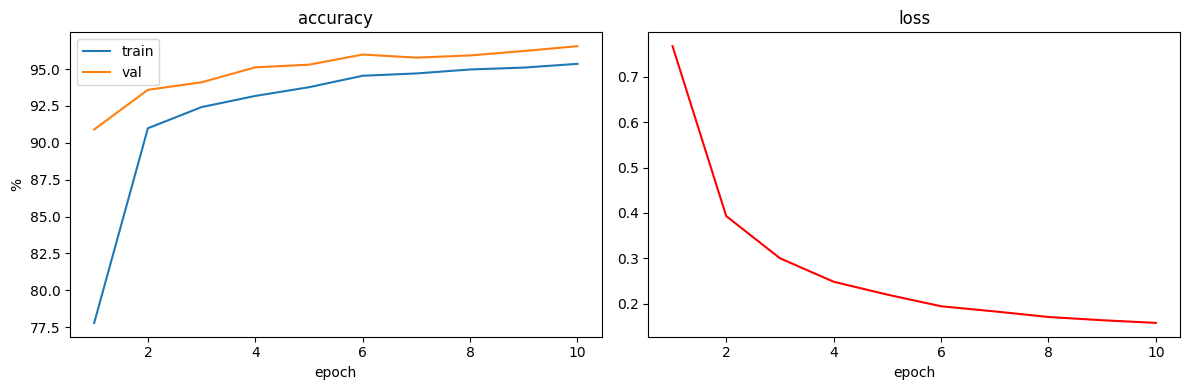

In [11]:
epochs = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_accs, label="train")
ax1.plot(epochs, val_accs,   label="val")
ax1.set_xlabel("epoch")
ax1.set_ylabel("%")
ax1.set_title("accuracy")
ax1.legend()

ax2.plot(epochs, losses, color="red")
ax2.set_xlabel("epoch")
ax2.set_title("loss")

plt.tight_layout()
plt.savefig("accuracy_loss.png", dpi=150)
plt.show()

### observation

The accuracy increased and the loss decreased over the training epochs, indicating that the model learned effectively from the dataset.

# 6. Sample Predictions

To evaluate the model, 50 random images are being selected from the validation dataset.

For each image, the model predicted a class and then calculated a confidence score. The predicted label and the confidence percentage are being displayed on the image.

- Green title indicates a correct prediction.
- Red title indicates an incorrect prediction.

This visualization helps in understanding how well the model performs on unseen images.

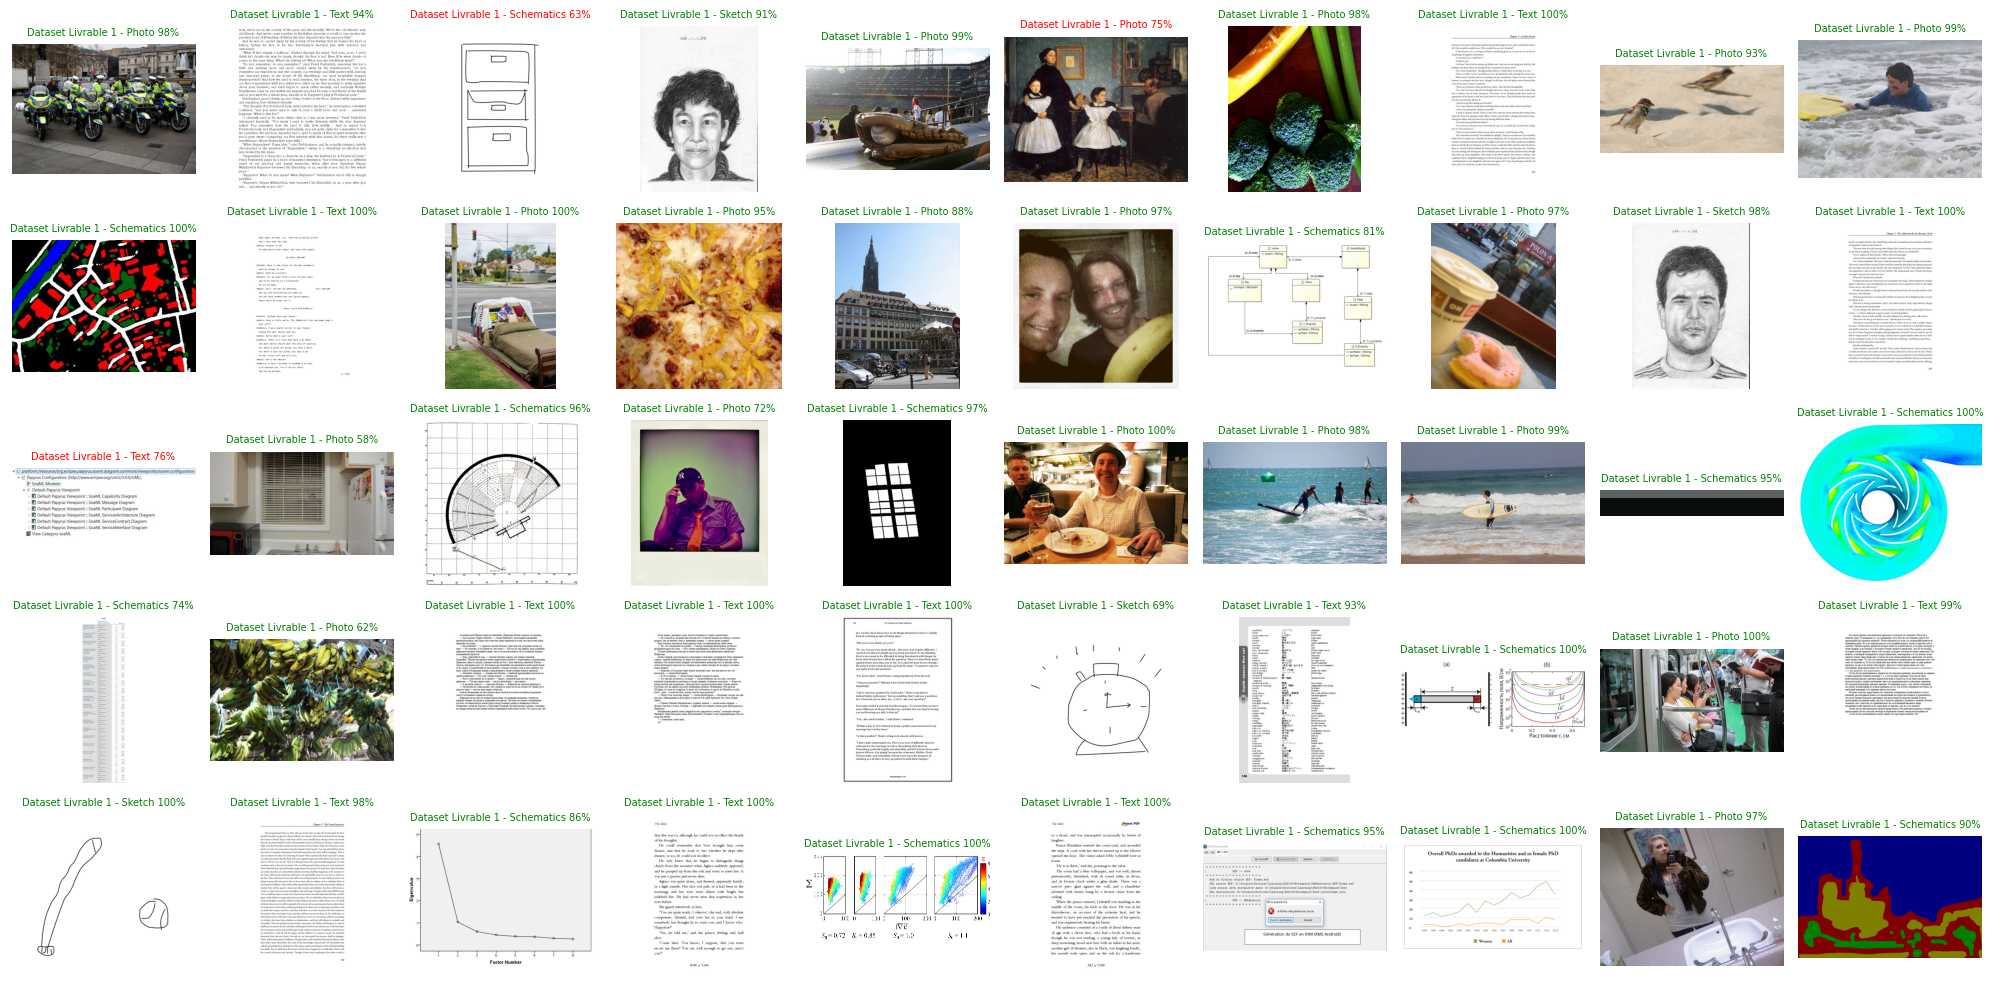

In [12]:
samples = random.sample(glob.glob(f"{DEST}/val/*/*"), 50)
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.flatten()

for i, path in enumerate(samples):
    actual = path.split("/")[-2]
    img = Image.open(path).convert("RGB")
    x = val_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(x), dim=1)
        conf, idx = prob.max(1)
    pred = classes[idx.item()]
    conf = conf.item() * 100
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{pred} {conf:.0f}%",
                      fontsize=7,
                      color="green" if pred == actual else "red")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()

## Observation

Tested the model on 50 random images from the validation set. Most of them came out correct with pretty high confidence scores. The few that were wrong had low confidence. Overall the predictions looked good and reliable across different classes.

# 7. Confusion Matrix

The confusion matrix is used to visualize the model's classification performance across all classes. It shows the number of correct and incorrect predictions made for each category. So most of the predictions are correctly classified along the diagonal of the matrix, indicating strong model performance. Any off-diagonal values represent misclassifications and help identify which classes were occasionally confused with one another.

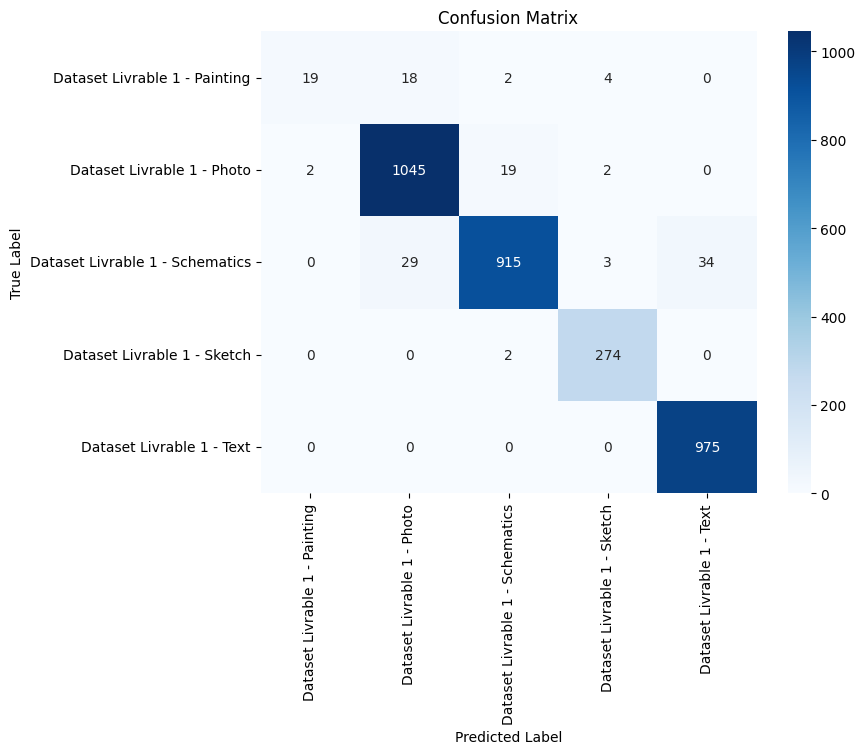

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Observation

The confusion matrix shows that most images were classified correctly. The highest accuracy is achieved for the Photo, Sketch, and Text classes. Only a few images were misclassified, indicating that the model learned the differences between the classes well.

# 8. Classification Report

Classification report is generated to evaluate the model's performance for each class. This report includes precision, recall, F1-score, and support values.

In [15]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

                                 precision    recall  f1-score   support

  Dataset Livrable 1 - Painting       0.90      0.44      0.59        43
     Dataset Livrable 1 - Photo       0.96      0.98      0.97      1068
Dataset Livrable 1 - Schematics       0.98      0.93      0.95       981
    Dataset Livrable 1 - Sketch       0.97      0.99      0.98       276
      Dataset Livrable 1 - Text       0.97      1.00      0.98       975

                       accuracy                           0.97      3343
                      macro avg       0.95      0.87      0.90      3343
                   weighted avg       0.97      0.97      0.96      3343



## Observation
This model has achieved an overall accuracy of 97%, showing very good performance. It has classified Photo, Schematics, Sketch, and Text images accurately. The Painting class has the lower performance as compared to the other classes. Overally the model is able to correctly classify most of images and performed well on unseen data.

# 9. Conclusion

In this project, I built an image classification model using a CNN-based ResNet18 architecture with transfer learning. The dataset was split into training and validation sets, and image preprocessing techniques such as resizing, normalization, random cropping, and flipping were applied.

The model was trained for 10 epochs and achieved a validation accuracy of 96.6%. The classification report and confusion matrix showed that most images were classified correctly, with only a few misclassifications between similar classes.

Overall, the model performed well and demonstrated that transfer learning with ResNet18 is an effective approach for image classification tasks.